##  Predict the number of furniture items sold (sold) based on product attributes 

###  1. Data Collection

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
import numpy as np

In [5]:
df = pd.read_csv('ecommerce_furniture_dataset_2024.csv')

In [6]:
print(df.head())

                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           NaN   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           NaN  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           NaN  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     0  Free shipping  
2     7  Free shipping  
3     0  Free shipping  
4     1  Free shipping  


### 2. Data Preprocessing

In [7]:
print(df.isnull().sum())

productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


In [5]:
df = df.dropna()

In [8]:
df['tagText'] = df['tagText'].astype('category').cat.codes

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        2000 non-null   int8  
dtypes: int64(1), int8(1), object(3)
memory usage: 64.6+ KB
None


### 3. Exploratory Data Analysis (EDA)

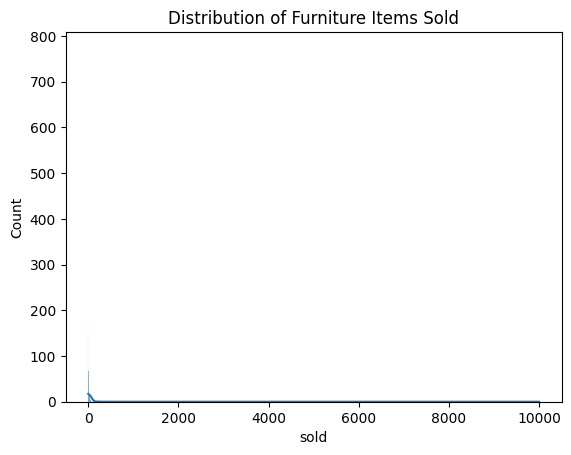

In [10]:
sns.histplot(df['sold'], kde=True)
plt.title('Distribution of Furniture Items Sold')
plt.show()

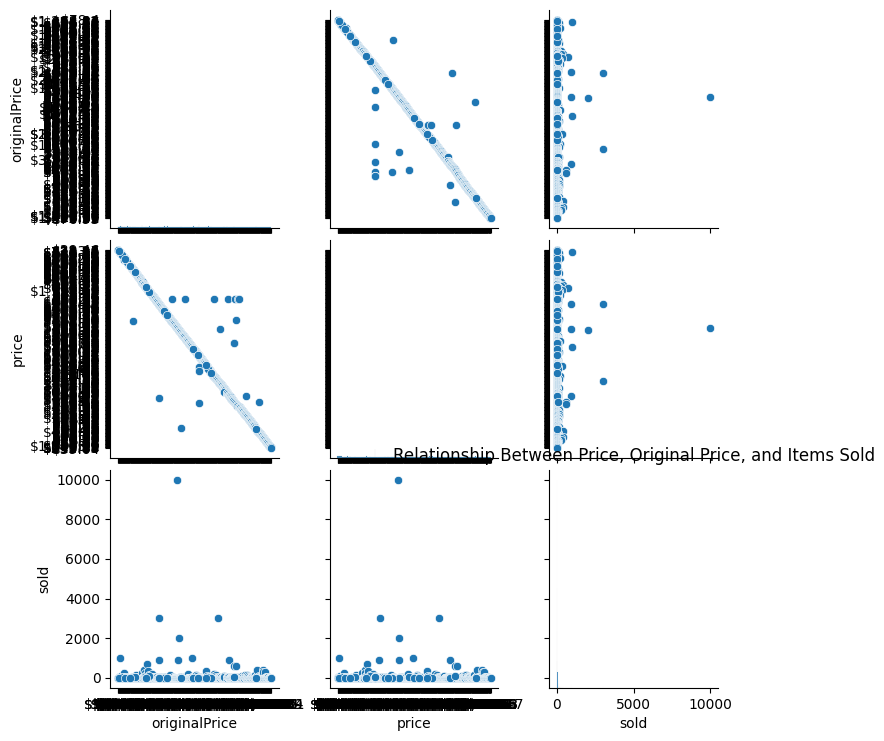

In [13]:
sns.pairplot(df, vars=['originalPrice', 'price', 'sold'], kind='scatter')
plt.title('Relationship Between Price, Original Price, and Items Sold')
plt.show()

### 4. Feature Engineering

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [23]:
df['originalPrice'] = df['originalPrice'].replace(r'[\$,]', '', regex=True).astype(float)

In [24]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 487 entries, 2 to 1983
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   productTitle   487 non-null    object 
 1   originalPrice  487 non-null    float64
 2   price          487 non-null    float64
 3   sold           487 non-null    int64  
 4   tagText        487 non-null    int8   
dtypes: float64(2), int64(1), int8(1), object(1)
memory usage: 19.5+ KB


,originalPrice,price,sold,tagText
count,487.000000,487.000000,487.000000,487.000000
mean,256.028090,120.593162,75.667351,1.993840
std,422.737861,179.599224,510.047670,0.101242
min,3.630000,0.990000,0.000000,0.000000
25%,31.770000,19.995000,4.000000,2.000000
50%,88.310000,44.620000,10.000000,2.000000
75%,314.125000,161.565000,28.000000,2.000000
max,3265.130000,1529.580000,10000.000000,2.000000


In [25]:
df['discount_percentage'] = ((df['originalPrice'] - 
df['price']) / df['originalPrice']) * 100

In [31]:
tfidf = TfidfVectorizer(max_features=100)
productTitle_tfidf = tfidf.fit_transform(df['productTitle'])

In [32]:
# Create a DataFrame from the TF-IDF matrix
productTitle_tfidf_df = pd.DataFrame( productTitle_tfidf.toarray(), columns=tfidf.get_feature_names_out())
# Concatenate the original df and the new tf-idf DataFrame along columns
df = pd.concat([df, productTitle_tfidf_df], axis=1)

In [33]:
df = df.drop('productTitle', axis=1)

In [34]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 877 entries, 2 to 486
Columns: 105 entries, originalPrice to wooden
dtypes: float64(105)
memory usage: 726.3 KB


,originalPrice,price,sold,tagText,discount_percentage,adjustable,and,bed,bedroom,bedside,...,under,upholstered,vanity,velvet,wardrobe,white,wicker,with,wood,wooden
count,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,...,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000
mean,256.028090,120.593162,75.667351,1.993840,47.208955,0.025430,0.050612,0.037818,0.050189,0.025566,...,0.011465,0.019866,0.026402,0.015925,0.044421,0.019186,0.016581,0.085363,0.017261,0.015857
std,422.737861,179.599224,510.047670,0.101242,18.510588,0.091589,0.102279,0.139791,0.096911,0.110766,...,0.070344,0.079743,0.110668,0.075331,0.154156,0.077063,0.070759,0.104225,0.083208,0.083499
min,3.630000,0.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.770000,19.995000,4.000000,2.000000,41.411767,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,88.310000,44.620000,10.000000,2.000000,48.633195,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,314.125000,161.565000,28.000000,2.000000,55.843427,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156465,0.000000,0.000000
max,3265.130000,1529.580000,10000.000000,2.000000,91.458154,0.641952,0.453829,0.876356,0.466517,0.782266,...,0.700810,0.466101,0.722371,0.570564,0.890392,0.524109,0.408731,0.467589,0.753420,0.654965


### 5. Model Selection & Training

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
print(df.isnull().sum())

originalPrice          390
price                  390
sold                   390
tagText                390
discount_percentage    390
                      ... 
white                  390
wicker                 390
with                   390
wood                   390
wooden                 390
Length: 105, dtype: int64


In [37]:
df = df.dropna()

In [38]:
print(df.isnull().sum())

originalPrice          0
price                  0
sold                   0
tagText                0
discount_percentage    0
                      ..
white                  0
wicker                 0
with                   0
wood                   0
wooden                 0
Length: 105, dtype: int64


In [39]:
X = df.drop('sold', axis=1)
y = df['sold']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.0


In [45]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 1. Create the model
lr_model = LinearRegression()
# 2. Train the model
lr_model.fit(X_train, y_train)
# 3. Predict on test set
lr_preds = lr_model.predict(X_test)
# 4. See the predictions
print(lr_preds)

[ -370.70640899  1338.56857274   383.73565905   143.66784115
   187.13210089  -267.35340962    13.5068104  -1069.69691198
   245.69282433   549.61942517  -629.86452952  -746.86751285
  1188.00715554     5.20344627   -67.54796892   -66.04749329
  1255.20869971   135.08960006   144.36503284   228.96803507]


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(rf_preds)

[ 22.93   5.61  78.25 229.75  59.54  54.7  200.54  15.66  20.28  22.71
  22.32  20.81  54.43   9.92  60.77  22.7  163.31  14.48  22.8   79.68]


In [51]:
print("Linear Regression MSE:", mean_squared_error(y_test, lr_preds))
print("Random Forest Regression MSE:", mean_squared_error(y_test, rf_preds))

Linear Regression MSE: 385345.9606710384
Random Forest Regression MSE: 6287.693744999999


### 6. Model Evaluation

In [54]:
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [53]:
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [56]:
print(f'Linear Regression MSE: {mse_lr}, R2: {r2_lr}')
print(f'Random Forest MSE: {mse_rf}, R2: {r2_rf}')

Linear Regression MSE: 385345.9606710384, R2: -1422.5823991541479
Random Forest MSE: 6287.693744999999, R2: -22.228607693373352


### 7. Conclusion

#### After evaluating the models, we can conclude which model performed better and further tune hyperparameters if needed. Random Forest tends to perform better on complex datasets with high variance, while Linear Regression might work well if relationships are linear

### Output:

#### 1. Linear Regression Model: MSE and R-squared score: MSE: 385,345.96 R²: -1422.58
#### 2. Random Forest Model:MSE: 6,287.69 R²: -22.23